<a href="https://colab.research.google.com/github/Aditya-Kayasth/Information-Retrival/blob/main/DS_A1_08_ADITYA_KAYASTH_IR_LAB_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Create data Structure that stores list of words and perform search on it
# Implement prefix trie for list of words
# Implement prefix trie for a sentence (Note: use tokenization for word)

### Trie (Prefix Tree)
A Trie, also known as a prefix tree, is a specialized tree-like data structure used to store a dynamic set or associative array where the keys are usually strings. Unlike a binary search tree, no node in the tree stores the key associated with that node; instead, its position in the tree defines the key with which it is associated. All children of a node have a common prefix of the string associated with that node.

**Advantages of Tries:**
*   **Efficient Prefix Search:** Tries allow for very fast prefix matching and searching for words with a given prefix.
*   **Alphabetical Ordering:** Keys can be retrieved in alphabetical order by doing a pre-order traversal.
*   **Space Efficiency (sometimes):** If many words share common prefixes, tries can be more space-efficient than hash tables.

In [3]:
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False

class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word: str) -> None:
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
        node.is_end_of_word = True

    def search(self, word: str) -> bool:
        node = self.root
        for char in word:
            if char not in node.children:
                return False
            node = node.children[char]
        return node.is_end_of_word

    def starts_with(self, prefix: str) -> bool:
        node = self.root
        for char in prefix:
            if char not in node.children:
                return False
            node = node.children[char]
        return True


In [2]:
words = ['Mango', 'Oranges', 'Banana', 'Coconut','Tomato']

print('Mango' in words)
print('Mangoes' in words)

True
False


In [4]:
# Create a Trie instance
trie = Trie()

# Insert words into the trie (converting to lowercase for case-insensitive search)
for word in words:
    trie.insert(word.lower())

# Perform searches
print(f"'Mango' in trie: {trie.search('mango')}")
print(f"'Mangoes' in trie: {trie.search('mangoes')}")
print(f"'Orange' prefix exists: {trie.starts_with('orange')}")
print(f"'Cocon' prefix exists: {trie.starts_with('cocon')}")
print(f"'Tomat' prefix exists: {trie.starts_with('tomat')}")
print(f"'Ban' prefix exists: {trie.starts_with('ban')}")
print(f"'Apple' in trie: {trie.search('apple')}")


'Mango' in trie: True
'Mangoes' in trie: False
'Orange' prefix exists: True
'Cocon' prefix exists: True
'Tomat' prefix exists: True
'Ban' prefix exists: True
'Apple' in trie: False


### Trie for a Sentence with Tokenization
To implement a prefix trie for a sentence, we first need to break down the sentence into individual words. This process is called tokenization. Once we have the words, we can insert them into our existing `Trie` data structure.

Here, we'll use a basic approach to tokenize a sentence by splitting it into words and converting them to lowercase for consistent searching.

In [5]:
import re

def tokenize_sentence(sentence):
    # Convert to lowercase and remove non-alphanumeric characters except spaces
    clean_sentence = re.sub(r'[^a-z0-9\s]', '', sentence.lower())
    # Split by spaces to get words
    words_in_sentence = clean_sentence.split()
    return words_in_sentence

# Example sentence
sentence = "Mangoes are sweet, and oranges are citrusy!"

# Tokenize the sentence
tokenized_words = tokenize_sentence(sentence)
print(f"Original Sentence: '{sentence}'")
print(f"Tokenized Words: {tokenized_words}")

# Create a new Trie instance for the sentence
sentence_trie = Trie()

# Insert tokenized words into the sentence trie
for word in tokenized_words:
    sentence_trie.insert(word)

# Perform searches on the sentence trie
print(f"'mangoes' in sentence trie: {sentence_trie.search('mangoes')}")
print(f"'sweet' in sentence trie: {sentence_trie.search('sweet')}")
print(f"'citrusy' in sentence trie: {sentence_trie.search('citrusy')}")
print(f"'apple' in sentence trie: {sentence_trie.search('apple')}")
print(f"Prefix 'oran' in sentence trie: {sentence_trie.starts_with('oran')}")
print(f"Prefix 'man' in sentence trie: {sentence_trie.starts_with('man')}")
print(f"Prefix 'swe' in sentence trie: {sentence_trie.starts_with('swe')}")


Original Sentence: 'Mangoes are sweet, and oranges are citrusy!'
Tokenized Words: ['mangoes', 'are', 'sweet', 'and', 'oranges', 'are', 'citrusy']
'mangoes' in sentence trie: True
'sweet' in sentence trie: True
'citrusy' in sentence trie: True
'apple' in sentence trie: False
Prefix 'oran' in sentence trie: True
Prefix 'man' in sentence trie: True
Prefix 'swe' in sentence trie: True


### Dictionary-Based Prefix Search
As an alternative to a Trie, especially for smaller datasets, you can implement a prefix search using a standard Python dictionary. This approach pre-computes all possible prefixes for each word and stores them as keys, with the corresponding words as values (typically in a list).

**Implementation:**
1.  For each word, generate all its prefixes (e.g., for 'mango', generate 'm', 'ma', 'man', 'mang', 'mango').
2.  Store these prefixes as keys in a dictionary. The value for each prefix key will be a set (to avoid duplicates) of words that start with that prefix.

**Note:** While simpler to understand, this can consume more memory and might not be as performant as a Trie for very large lexicons, especially when generating all possible prefixes.

In [6]:
from collections import defaultdict

def build_prefix_dictionary(word_list):
    prefix_dict = defaultdict(set)
    for word in word_list:
        for i in range(1, len(word) + 1):
            prefix = word[:i]
            prefix_dict[prefix].add(word)
    # Convert sets to lists for easier display/use if preferred
    return {prefix: sorted(list(words)) for prefix, words in prefix_dict.items()}

def search_prefix_dict(prefix_dict, query_prefix):
    return prefix_dict.get(query_prefix, [])

print("\n--- Using prefix dictionary with original 'words' list ---")
# Ensure words are lowercase for consistent prefix matching
lowercase_words = [word.lower() for word in words]
prefix_lookup_words = build_prefix_dictionary(lowercase_words)

print(f"'m' prefix matches: {search_prefix_dict(prefix_lookup_words, 'm')}")
print(f"'man' prefix matches: {search_prefix_dict(prefix_lookup_words, 'man')}")
print(f"'ora' prefix matches: {search_prefix_dict(prefix_lookup_words, 'ora')}")
print(f"'app' prefix matches: {search_prefix_dict(prefix_lookup_words, 'app')}")

print("\n--- Using prefix dictionary with 'tokenized_words' from sentence ---")
prefix_lookup_sentence = build_prefix_dictionary(tokenized_words)

print(f"'man' prefix matches: {search_prefix_dict(prefix_lookup_sentence, 'man')}")
print(f"'swe' prefix matches: {search_prefix_dict(prefix_lookup_sentence, 'swe')}")
print(f"'cit' prefix matches: {search_prefix_dict(prefix_lookup_sentence, 'cit')}")
print(f"'app' prefix matches: {search_prefix_dict(prefix_lookup_sentence, 'app')}")



--- Using prefix dictionary with original 'words' list ---
'm' prefix matches: ['mango']
'man' prefix matches: ['mango']
'ora' prefix matches: ['oranges']
'app' prefix matches: []

--- Using prefix dictionary with 'tokenized_words' from sentence ---
'man' prefix matches: ['mangoes']
'swe' prefix matches: ['sweet']
'cit' prefix matches: ['citrusy']
'app' prefix matches: []


### Visualizing the Trie using Graphviz
To visualize the Trie, we can use the `graphviz` library. This involves traversing the Trie and representing each node and its children as part of a DOT graph, which `graphviz` can then render into an image.

First, we need to install the `graphviz` library if it's not already installed.

In [7]:
!pip install graphviz
import graphviz


Visualizing Trie for words list...


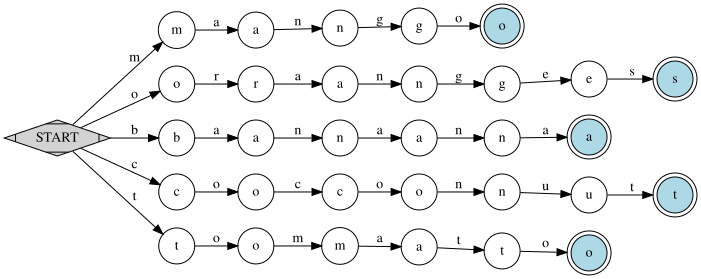

In [9]:
def visualize_trie(trie_root, title="Trie Visualization"):
    dot = graphviz.Digraph(comment=title, graph_attr={'rankdir': 'LR'})
    node_counter = 0

    def add_nodes_edges(node, parent_id, char):
        nonlocal node_counter
        current_id = str(node_counter)
        node_counter += 1

        label = char if char is not None else 'ROOT'
        if node.is_end_of_word:
            dot.node(current_id, label=label, shape='doublecircle', style='filled', fillcolor='lightblue')
        else:
            dot.node(current_id, label=label, shape='circle')

        if parent_id is not None:
            dot.edge(parent_id, current_id, label=char)

        for child_char, child_node in node.children.items():
            add_nodes_edges(child_node, current_id, child_char)

    # Add a dummy root node for visualization purposes if the actual root is implicit
    # or if we want to differentiate it clearly.
    # For a Trie, the root usually doesn't represent a character itself.
    dot.node('root_start', label='START', shape='Mdiamond', fillcolor='lightgrey', style='filled')

    # Connect START to actual root's children
    for char, child_node in trie_root.children.items():
        child_id = str(node_counter)
        node_counter += 1
        add_nodes_edges(child_node, 'root_start', char)

    return dot

print("Visualizing Trie for words list...")
dot_words = visualize_trie(trie.root, title="Trie for words list")
display(dot_words)





Visualizing Trie for sentence tokenized words...


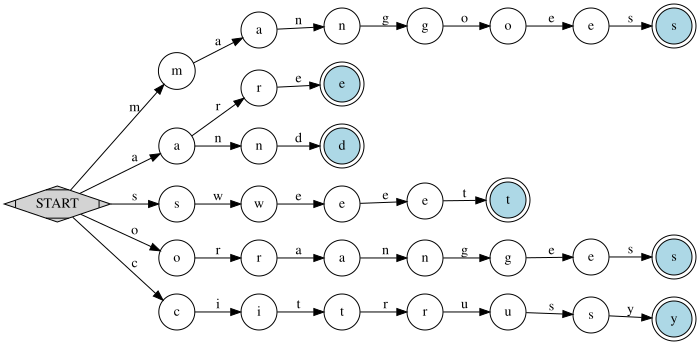

In [10]:
print("\nVisualizing Trie for sentence tokenized words...")
dot_sentence = visualize_trie(sentence_trie.root, title="Trie for Tokenized Sentence")
display(dot_sentence)